# Day 2 work

In [2]:
# Load same packages as in previous day
library(Seurat)
library(ggplot2)
library(Matrix)
library(reshape2)

Loading required package: SeuratObject

Loading required package: sp


Attaching package: ‘SeuratObject’


The following objects are masked from ‘package:base’:

    %||%, intersect, t



Attaching package: ‘Seurat’


The following object is masked from ‘package:base’:

    %||%




# Data loading

In [3]:
# Load the raw 10x H5 file
healthy.pbmc.data <- Read10X_h5("~/singlecell/data/5k_Human_Donor1_PBMC/filtered_feature_bc_matrix.h5")
# Create a Seurat object
healthy.pbmc <- CreateSeuratObject(healthy.pbmc.data, project = "PBMC")

# uncomment the following lines to load the ALL PBMC data
# ALL.pbmc.data <- Read10X_h5("~/singlecell/data/10k_5p_Human_diseased_PBMC_ALL_Fresh/10k_5p_Human_diseased_PBMC_ALL_Fresh_count_filtered_feature_bc_matrix.h5")
# ALL.pbmc <- CreateSeuratObject(ALL.pbmc.data, project = "ALL_PBMC")

In [6]:
# Mitochondrial gene percentage
healthy.pbmc[["percent.mt"]] <- PercentageFeatureSet(healthy.pbmc, pattern = "^MT-")

# Ribosomal gene percentage (optional but informative)
healthy.pbmc[["percent.ribo"]] <- PercentageFeatureSet(healthy.pbmc, pattern = "^RPL|^RPS")

In [7]:
# Re-QC the data as in the previous day

# Set thresholds -- you can elect to use the same thresholds, or adjust and see how that affects the downstream results
min_genes <- 200
max_genes <- 3000
max_mito  <- 10

healthy.pbmc_qc1 <- subset(
    healthy.pbmc,
    subset = nFeature_RNA > min_genes &
            nFeature_RNA < max_genes &
            percent.mt < max_mito
)

dim(healthy.pbmc_qc1)

[1] 38606  1695

# Data normalization

In [8]:
healthy.pbmc_qc1 <- NormalizeData(healthy.pbmc_qc1)

Normalizing layer: counts



In [12]:
# what does NormalizeData add to the Seurat object? Check the slot names and the assay data to see what has been added.
# compare the object before and after normalization to see what has changed.

# object without normalization
str(healthy.pbmc)

# Can you tell from the object slot names what normalization has been applied?

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ layers    :List of 1
  .. .. .. .. ..$ counts:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:19262779] 8 18 21 36 51 55 60 66 69 77 ...
  .. .. .. .. .. .. ..@ p       : int [1:5711] 0 7089 9193 12757 17128 20073 24235 26657 30348 33337 ...
  .. .. .. .. .. .. ..@ Dim     : int [1:2] 38606 5710
  .. .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. ..@ x       : num [1:19262779] 1 3 1 2 3 1 1 6 4 1 ...
  .. .. .. .. .. .. ..@ factors : list()
  .. .. .. ..@ cells     :Formal class 'LogMap' [package "SeuratObject"] with 1 slot
  .. .. .. .. .. ..@ .Data: logi [1:5710, 1] TRUE TRUE TRUE TRUE TRUE TRUE ...
  .. .. .. .. .. .. ..- attr(*, "dimnames")=List of 2
  .. .. .. .. .. .. .. ..$ : c

In [10]:
# object QCd and normalized
str(healthy.pbmc_qc1)

Formal class 'Seurat' [package "SeuratObject"] with 13 slots
  ..@ assays      :List of 1
  .. ..$ RNA:Formal class 'Assay5' [package "SeuratObject"] with 8 slots
  .. .. .. ..@ layers    :List of 2
  .. .. .. .. ..$ counts:Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:4427341] 94 107 194 204 218 247 250 310 352 374 ...
  .. .. .. .. .. .. ..@ p       : int [1:1696] 0 2104 5049 7471 10460 12971 15582 18404 20998 23635 ...
  .. .. .. .. .. .. ..@ Dim     : int [1:2] 38606 1695
  .. .. .. .. .. .. ..@ Dimnames:List of 2
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. .. ..$ : NULL
  .. .. .. .. .. .. ..@ x       : num [1:4427341] 1 1 1 3 2 2 1 8 5 1 ...
  .. .. .. .. .. .. ..@ factors : list()
  .. .. .. .. ..$ data  :Formal class 'dgCMatrix' [package "Matrix"] with 6 slots
  .. .. .. .. .. .. ..@ i       : int [1:4427341] 94 107 194 204 218 247 250 310 352 374 ...
  .. .. .. .. .. .. ..@ p       : int [1:1696] 0 2104 5049 7471 10

In [25]:
# raw counts are stored in "counts" slot of the RNA assay
dim(healthy.pbmc_qc1@assays$RNA$counts)

# normalized data are stored in "data" slot of the RNA assay
dim(healthy.pbmc_qc1@assays$RNA$data)

[1] 38606  1695

[1] 38606  1695

In [26]:
head(healthy.pbmc_qc1@assays$RNA$counts[, 1:20], 20)

  [[ suppressing 20 column names ‘AAACCCTGTGACGAGT-1’, ‘AAACGATGTCTTGAAC-1’, ‘AAACGATGTTAGCCCA-1’ ... ]]



20 x 20 sparse Matrix of class "dgCMatrix"
                                                       
DDX11L2         . . . . . . . . . . . . . . . . . . . .
MIR1302-2HG     . . . . . . . . . . . . . . . . . . . .
FAM138A         . . . . . . . . . . . . . . . . . . . .
ENSG00000290826 . . . . . . . . . . . . . . . . . . . .
OR4F5           . . . . . . . . . . . . . . . . . . . .
ENSG00000238009 . . . . . . . . . . . . . . . . . . . .
ENSG00000239945 . . . . . . . . . . . . . . . . . . . .
ENSG00000239906 . . . . . . . . . . . . . . . . . . . .
ENSG00000241860 . . . . . . . . . . . . . . . . . . . .
ENSG00000241599 . . . . . . . . . . . . . . . . . . . .
ENSG00000286448 . . . . . . . . . . . . . . . . . . . .
ENSG00000236601 . . . . . . . . . . . . . . . . . . . .
ENSG00000290385 . . . . . . . . . . . . . . . . . . . .
OR4F29          . . . . . . . . . . . . . . . . . . . .
ENSG00000235146 . . . . . . . . . . . . . . . . . . . .
OR4F16          . . . . . . . . . . . . . . . . . . . .
ENSG0

In [27]:
head(healthy.pbmc_qc1@assays$RNA$data[, 1:20], 20)

  [[ suppressing 20 column names ‘AAACCCTGTGACGAGT-1’, ‘AAACGATGTCTTGAAC-1’, ‘AAACGATGTTAGCCCA-1’ ... ]]



20 x 20 sparse Matrix of class "dgCMatrix"
                                                                             
DDX11L2         . . . . .         . .        . . . . . . . . . . . .        .
MIR1302-2HG     . . . . .         . .        . . . . . . . . . . . .        .
FAM138A         . . . . .         . .        . . . . . . . . . . . .        .
ENSG00000290826 . . . . .         . .        . . . . . . . . . . . .        .
OR4F5           . . . . .         . .        . . . . . . . . . . . .        .
ENSG00000238009 . . . . .         . .        . . . . . . . . . . . .        .
ENSG00000239945 . . . . .         . .        . . . . . . . . . . . .        .
ENSG00000239906 . . . . .         . .        . . . . . . . . . . . .        .
ENSG00000241860 . . . . .         . .        . . . . . . . . . . . .        .
ENSG00000241599 . . . . .         . .        . . . . . . . . . . . .        .
ENSG00000286448 . . . . .         . .        . . . . . . . . . . . .        .
ENSG00000236601 . . .

## Normalized vs. raw counts distribution

In [31]:
# what is the distribution of the normalized data, vs. raw counts?

# raw counts with zeroes removed
v_raw <- as.numeric(healthy.pbmc_qc1@assays$RNA$counts)
v_raw <- v_raw[v_raw > 0]

# normalized data with zeroes removed
v_norm <- as.numeric(healthy.pbmc_qc1@assays$RNA$data)
v_norm <- v_norm[v_norm > 0]

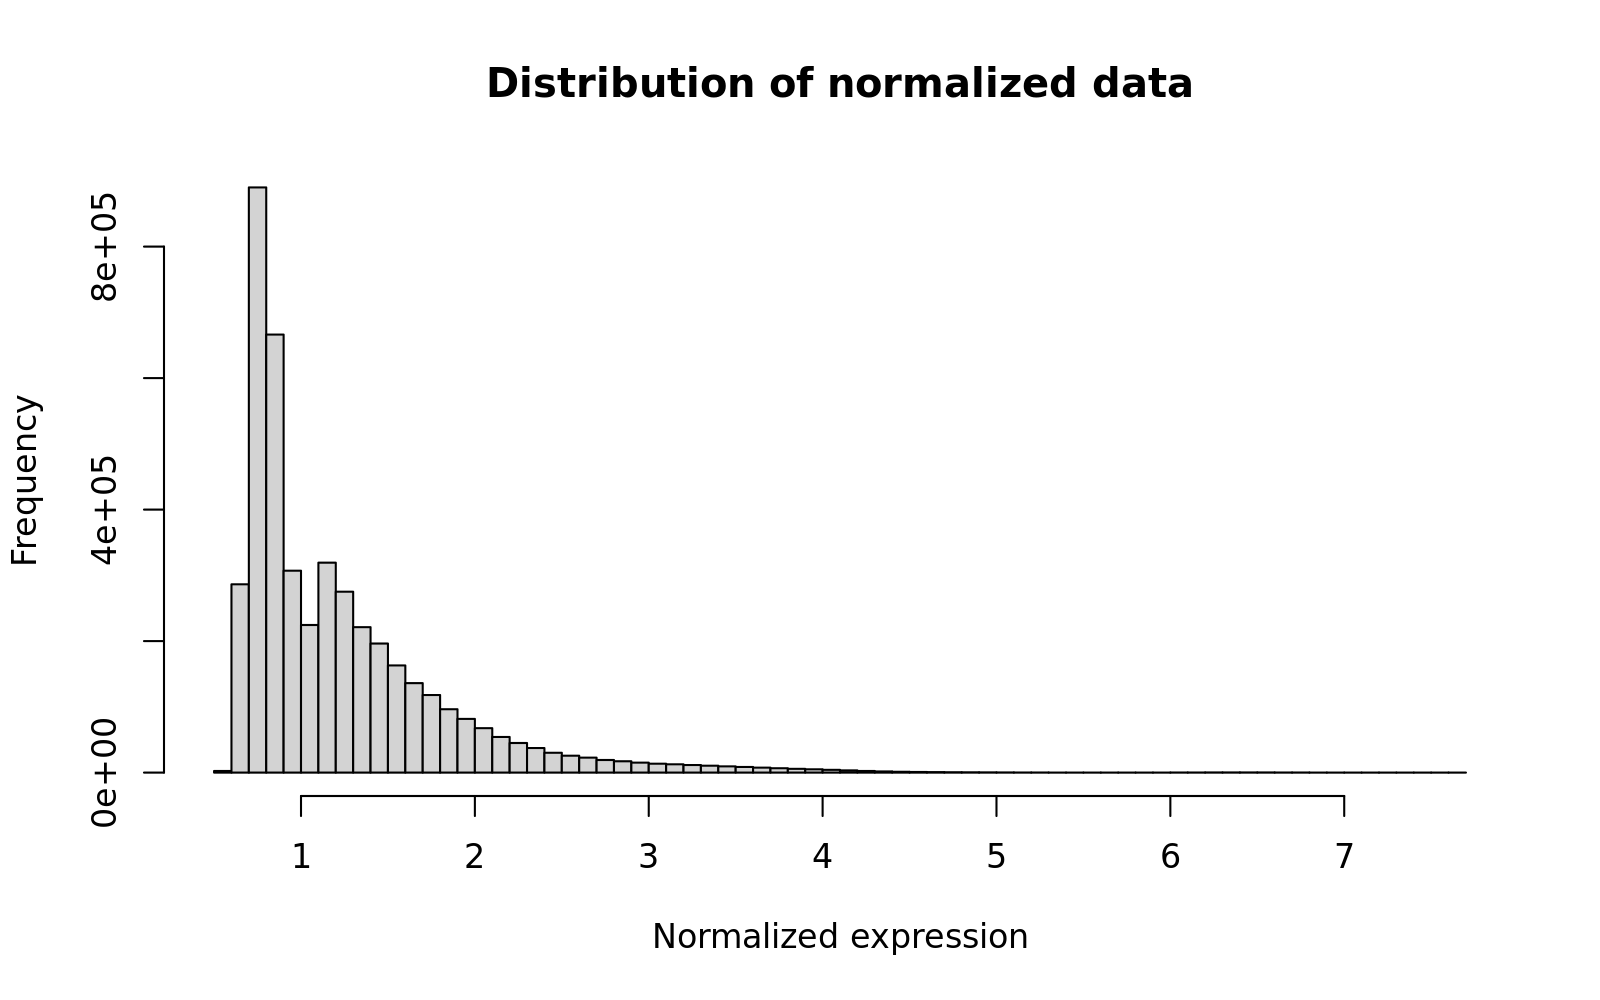

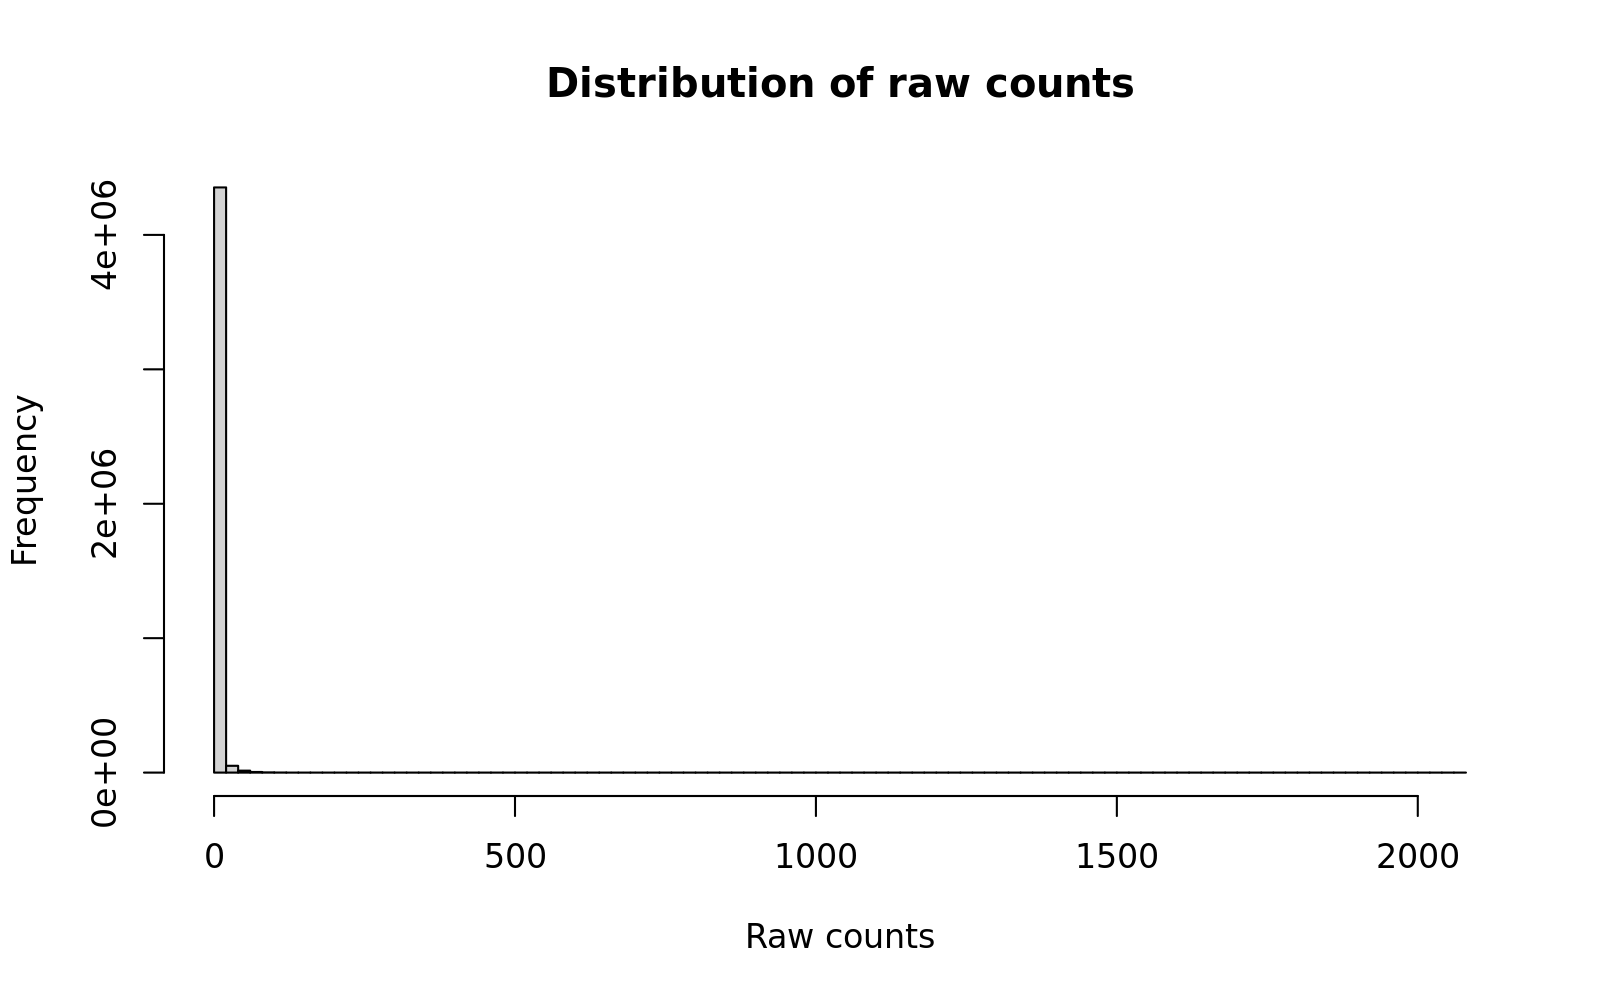

In [34]:
options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)

hist(v_norm, breaks = 100, main = "Distribution of normalized data", xlab = "Normalized expression")
hist(v_raw, breaks = 100, main = "Distribution of raw counts", xlab = "Raw counts")

# Find variable genes

Below, we filter genes for only those that are highly variable. Genes with little or no variation are not interesting for additional analyses, but what is the "correct" threshold?

The plots show which genes are selected as "highly variable" (in red), vs. those that are not (in black). The x-axes give the average expression, whereas y-axes give the standard variance.


Finding variable features for layer counts



Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


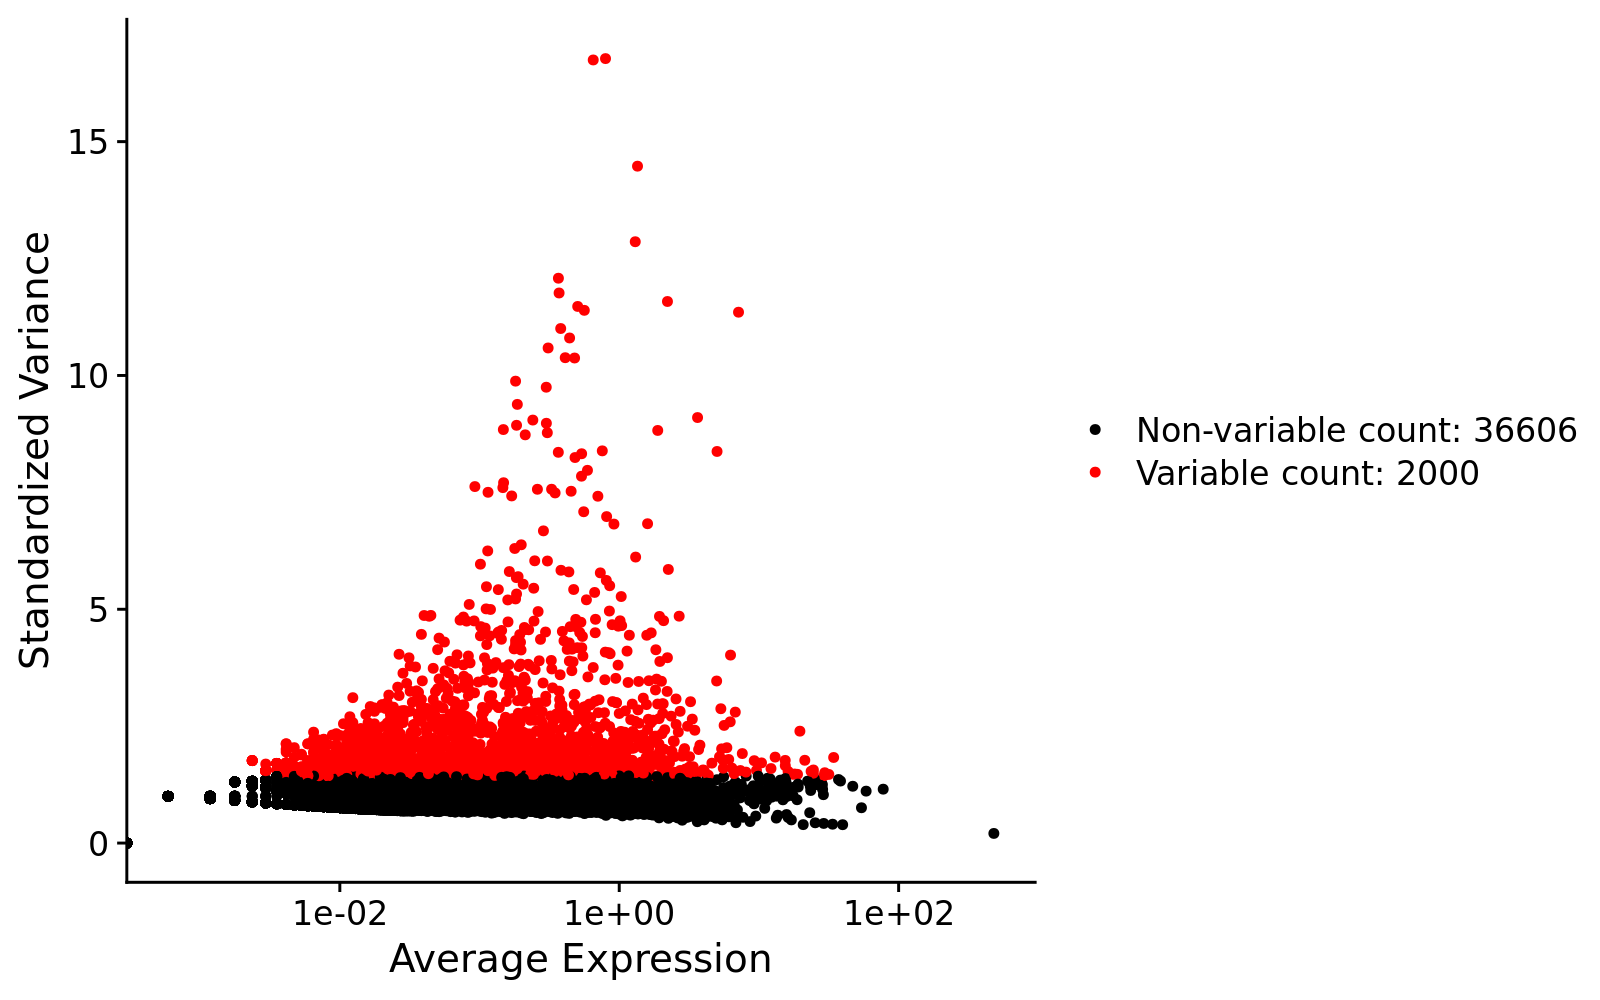

In [39]:
# you can select the top N variable features to keep for downstream analyses
# try a few different thresholds and see how that changes the result!

healthy.pbmc_qc1 <- FindVariableFeatures(
  healthy.pbmc_qc1,
  selection.method = "vst",
  nfeatures = 2000
)

options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
VariableFeaturePlot(healthy.pbmc_qc1)

Finding variable features for layer counts



Warning message in scale_x_log10():
“log-10 transformation introduced infinite values.”


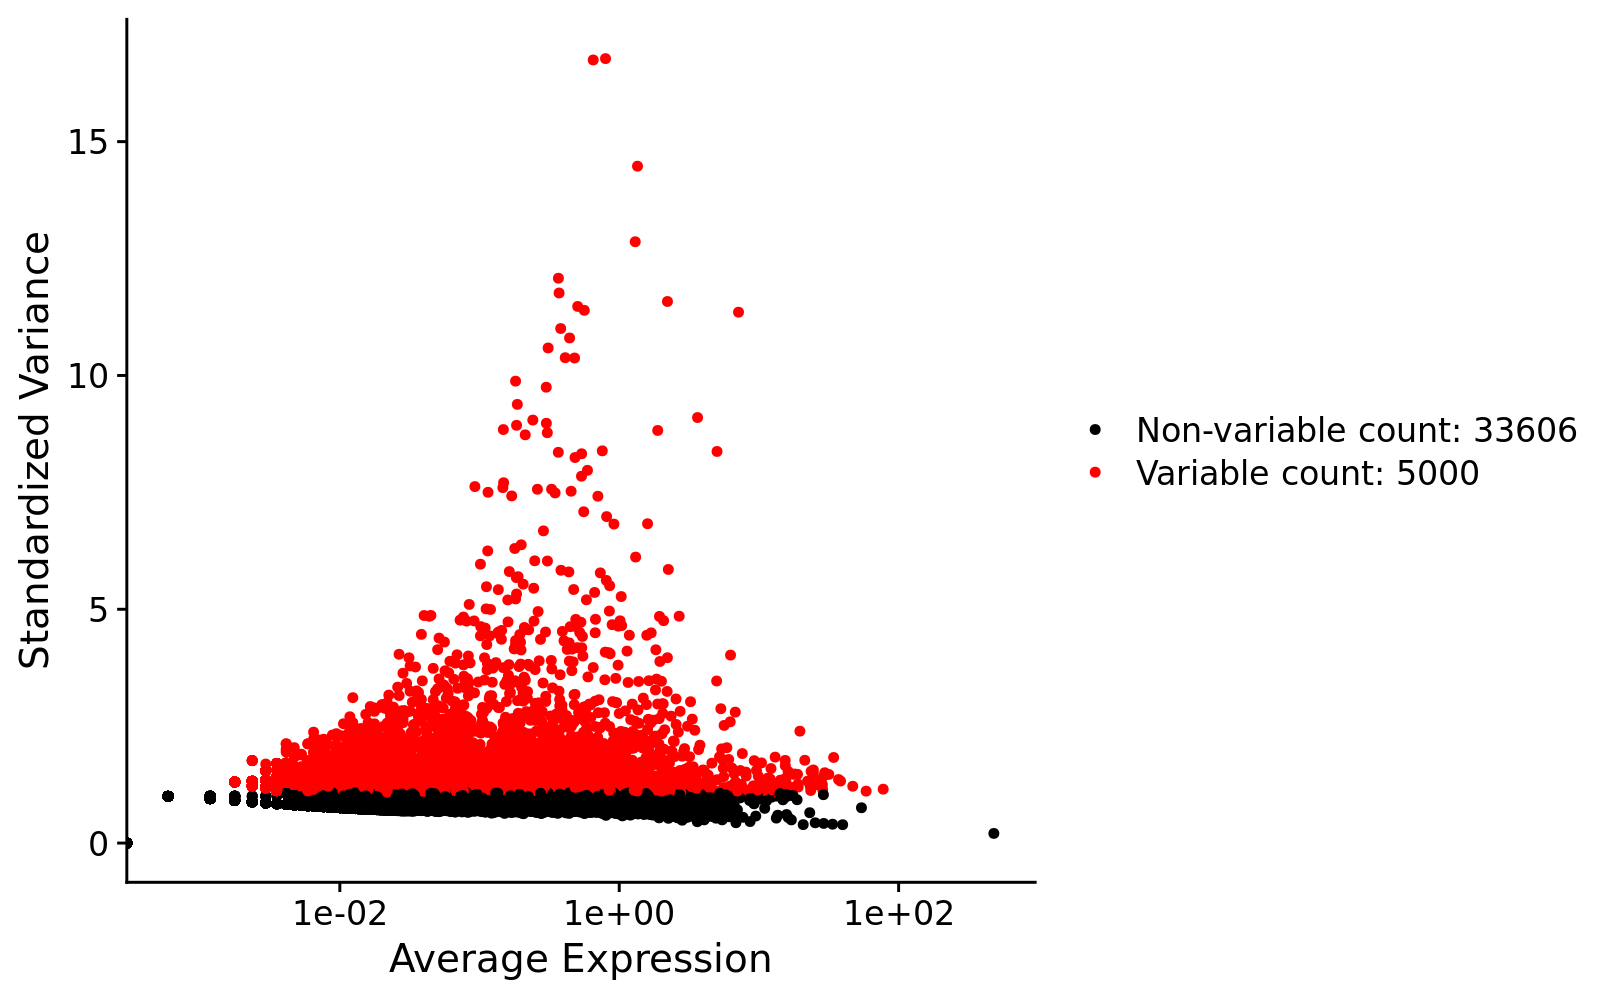

In [40]:
healthy.pbmc_qc1 <- FindVariableFeatures(
  healthy.pbmc_qc1,
  selection.method = "vst",
  nfeatures = 5000
)

options(repr.plot.width = 8, repr.plot.height = 5, repr.plot.res = 200)
VariableFeaturePlot(healthy.pbmc_qc1)

# PCA

PCA is a typical dimension reduction approach. The purpose is to project the data that in a much higher dimension (e.g., 2000 or 5000 genes) into a lower dimensional space (e.g., 2 axes for visualization).

PCA is a deterministic approach and produces PCs (principal components) that are linear combinations of the input features. **Compare this with non-deterministic methods such as UMAP.**

In [42]:
# run PCA
healthy.pbmc_qc1 <- ScaleData(healthy.pbmc_qc1)
healthy.pbmc_qc1 <- RunPCA(healthy.pbmc_qc1, npcs = 50, verbose = FALSE)

Centering and scaling data matrix



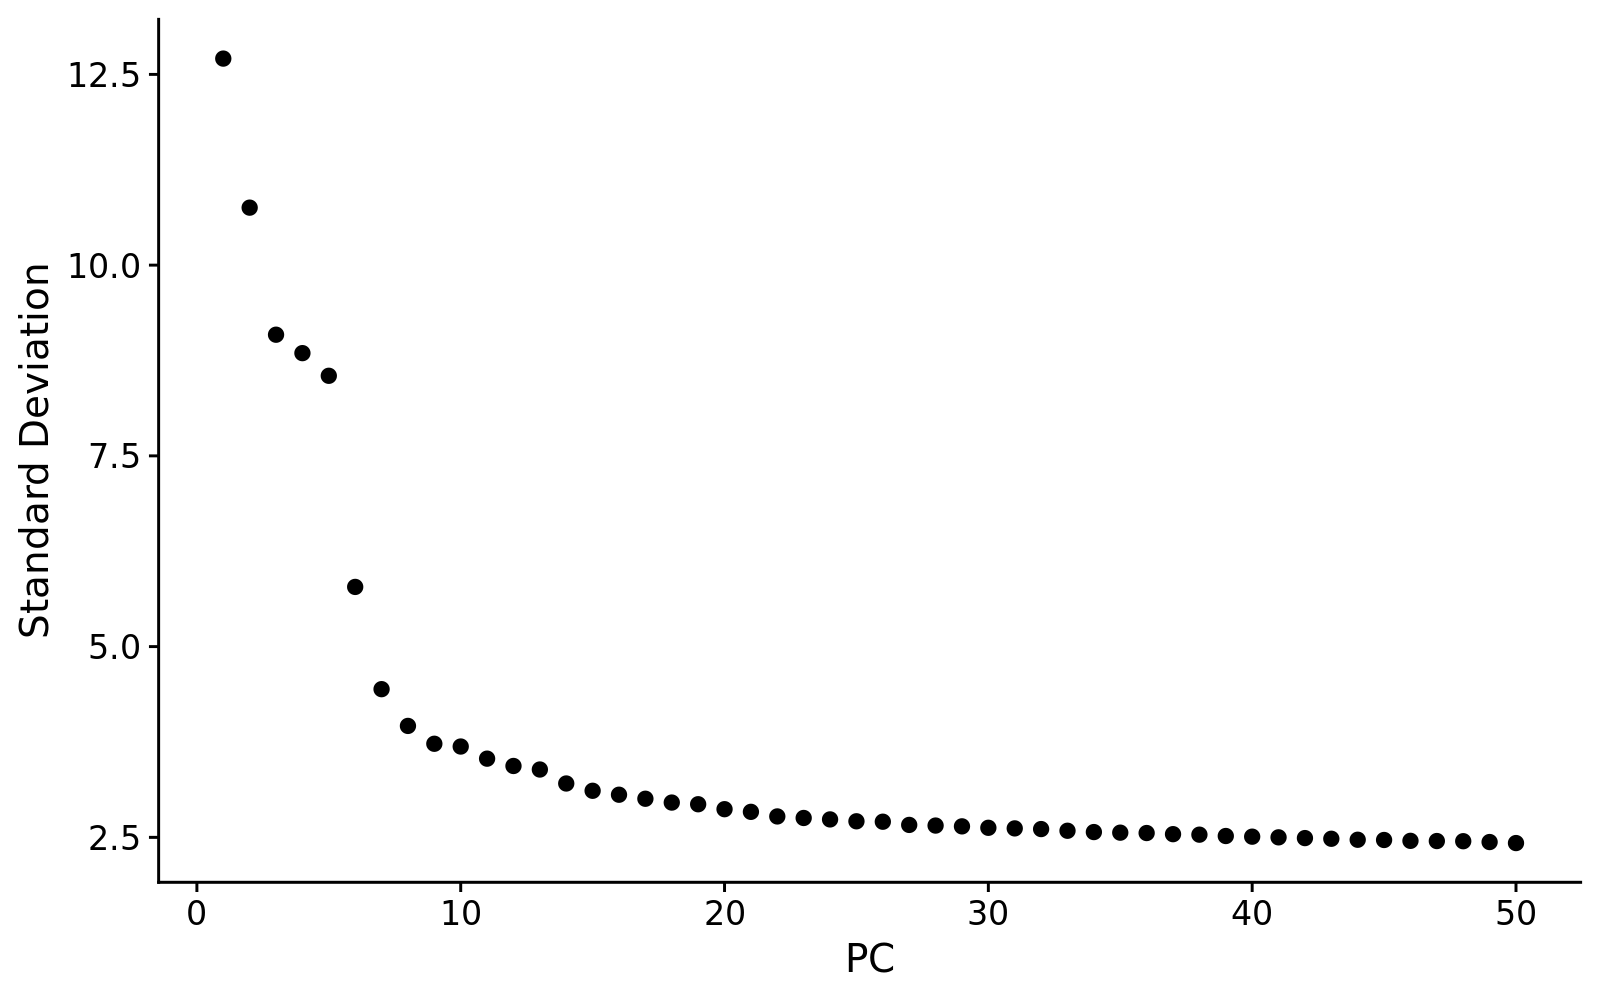

In [43]:
# Create an elbow plot to determine how many PCs to use for downstream analyses

# Elbow plot interpretation: 
# look for the "elbow" point where the variance explained by additional PCs starts to level off. 
# This is often a good cutoff for how many PCs to use in downstream analyses like clustering and UMAP. 
# In this case, you see a clear elbow around 5-7 PCs, suggesting that the top 5-7 PCs 
# would capture most of the meaningful variation in the data without including too much noise.

ElbowPlot(healthy.pbmc_qc1, ndims = 50)

# Cluster cells

In [47]:
# here we use the first 7 dimensions based on the elbow plot
dims_use <- 1:7

healthy.pbmc_qc1 <- FindNeighbors(healthy.pbmc_qc1, dims = dims_use)
healthy.pbmc_qc1 <- FindClusters(healthy.pbmc_qc1, resolution = 0.5)

Computing nearest neighbor graph



Computing SNN



Modularity Optimizer version 1.3.0 by Ludo Waltman and Nees Jan van Eck

Number of nodes: 1695
Number of edges: 47426

Running Louvain algorithm...
Maximum modularity in 10 random starts: 0.8957
Number of communities: 11
Elapsed time: 0 seconds


UMAP is a non-linear dimensionality reduction technique that is often used for visualizing high-dimensional single-cell data. It helps to capture the complex relationships between cells in a 2D or 3D space. However, it is **not** deterministic, and depending on how it is parameterized, can result in very different visuals.

My absolute favorite exploration of UMAP parameterization can be found here: https://pair-code.github.io/understanding-umap/

See the mammoth halfway down the page!

20:26:05 UMAP embedding parameters a = 0.9922 b = 1.112

20:26:05 Read 1695 rows and found 7 numeric columns

20:26:05 Using Annoy for neighbor search, n_neighbors = 30

20:26:05 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*


*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

20:26:06 Writing NN index file to temp file /tmp/Rtmpr4N6Hz/filea1f74acc89f

20:26:06 Searching Annoy index using 1 thread, search_k = 3000

20:26:06 Annoy recall = 100%

20:26:07 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

20:26:08 Initializing from normalized Laplacian + noise (using RSpectra)

20:26:08 Commencing optimization for 500 epochs, with 62402 positive edges

20:26:08 Using rng type: pcg

20:26:11 Optimization finished



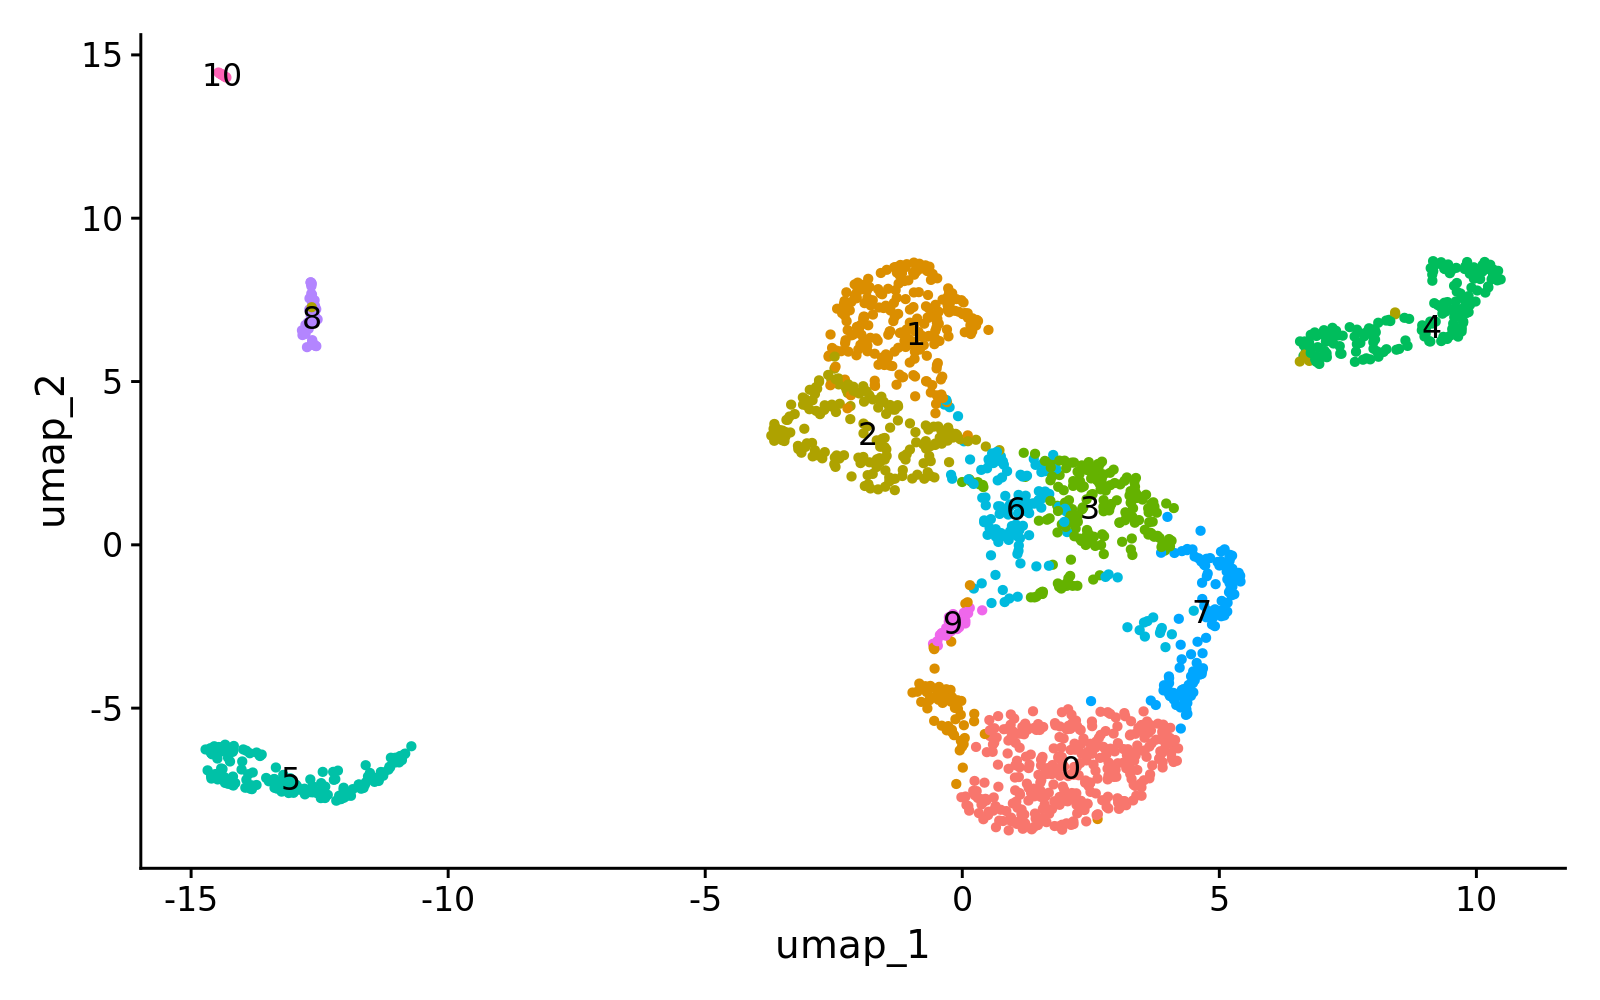

In [48]:
healthy.pbmc_qc1 <- RunUMAP(healthy.pbmc_qc1, dims = dims_use)
DimPlot(healthy.pbmc_qc1, reduction = "umap", label = TRUE) + NoLegend()

20:29:12 UMAP embedding parameters a = 0.9922 b = 1.112

20:29:12 Read 1695 rows and found 7 numeric columns

20:29:12 Using Annoy for neighbor search, n_neighbors = 3

20:29:12 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%



[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

20:29:13 Writing NN index file to temp file /tmp/Rtmpr4N6Hz/filea1f7b4bf710

20:29:13 Searching Annoy index using 1 thread, search_k = 300

20:29:13 Annoy recall = 100%

20:29:13 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 3

20:29:14 Found 19 connected components, 
falling back to 'spca' initialization with init_sdev = 1

20:29:14 Using 'irlba' for PCA

20:29:14 PCA: 2 components explained 49.11% variance

20:29:14 Scaling init to sdev = 1

20:29:14 Commencing optimization for 500 epochs, with 4912 positive edges

20:29:14 Using rng type: pcg

20:29:15 Optimization finished



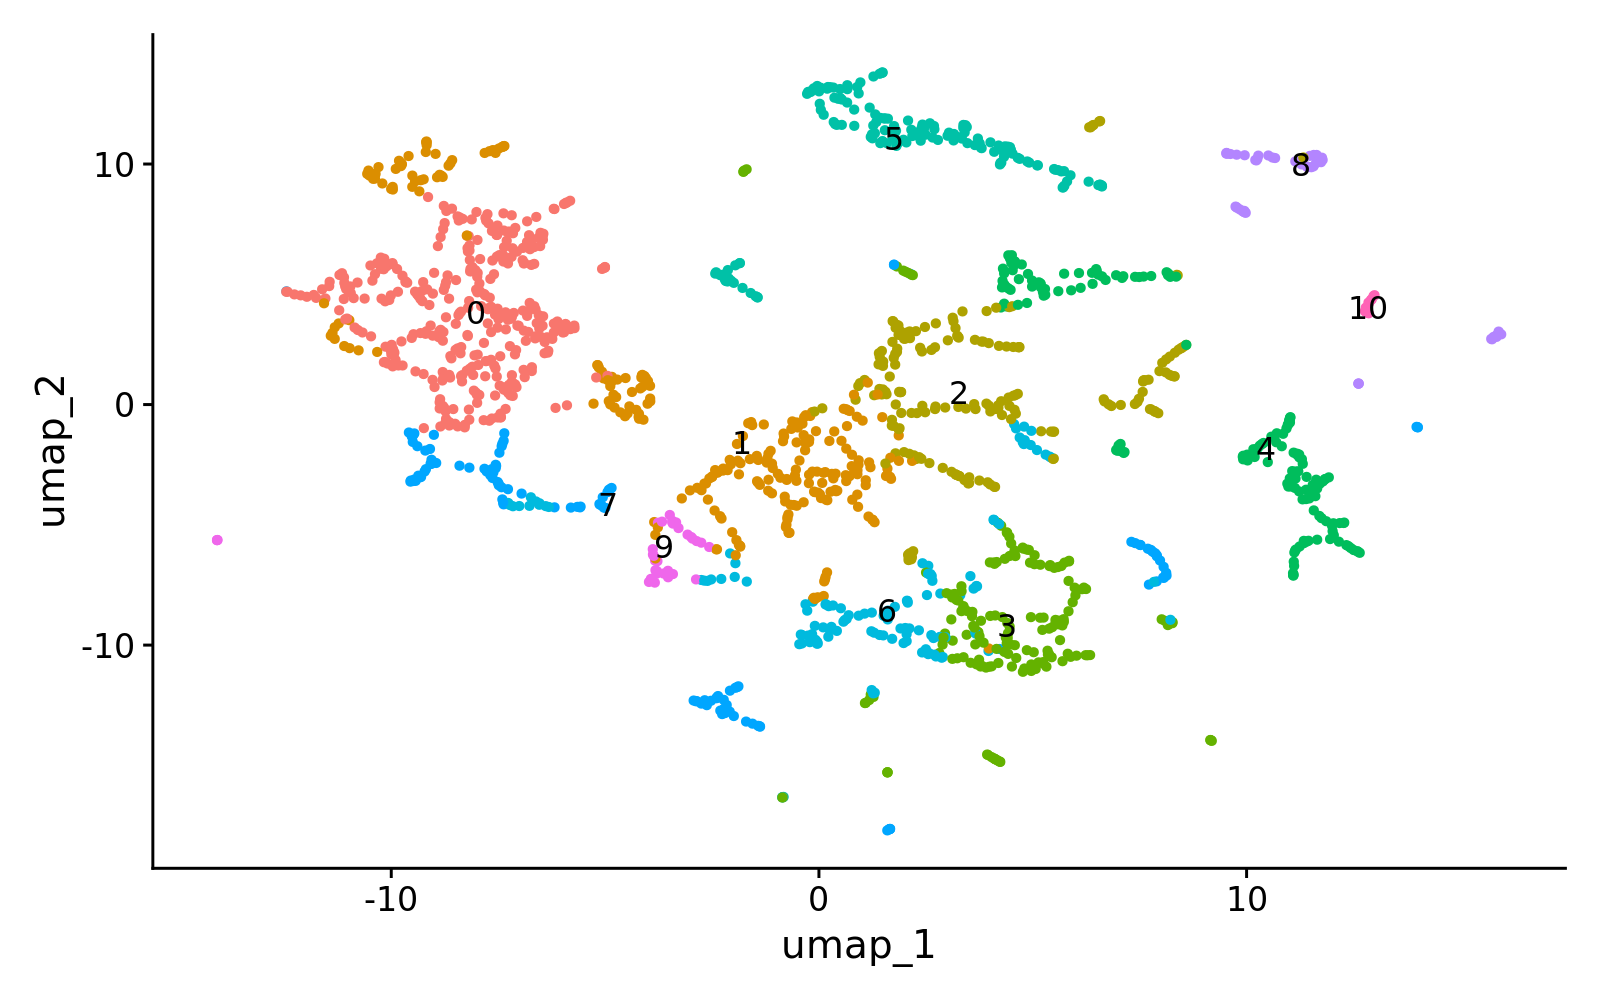

In [50]:
# try a few different UMAP parameters and see how that changes the result!

# here we use a much lower number of neighbors, which will make the UMAP plot more "fragmented" and less "connected"
healthy.pbmc_qc1 <- RunUMAP(healthy.pbmc_qc1, dims = dims_use, n.neighbors = 3, min.dist = 0.3)
DimPlot(healthy.pbmc_qc1, reduction = "umap", label = TRUE) + NoLegend()

20:29:32 UMAP embedding parameters a = 0.9922 b = 1.112

20:29:32 Read 1695 rows and found 7 numeric columns

20:29:32 Using Annoy for neighbor search, n_neighbors = 100

20:29:33 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

20:29:33 Writing NN index file to temp file /tmp/Rtmpr4N6Hz/filea1f35159a93

20:29:33 Searching Annoy index using 1 thread, search_k = 10000

20:29:35 Annoy recall = 100%

20:29:35 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 100

20:29:37 Initializing from normalized Laplacian + noise (using RSpectra)

20:29:37 Commencing optimization for 500 epochs, with 143604 positive edges

20:29:37 Using rng type: pcg

20:29:40 Optimization finished



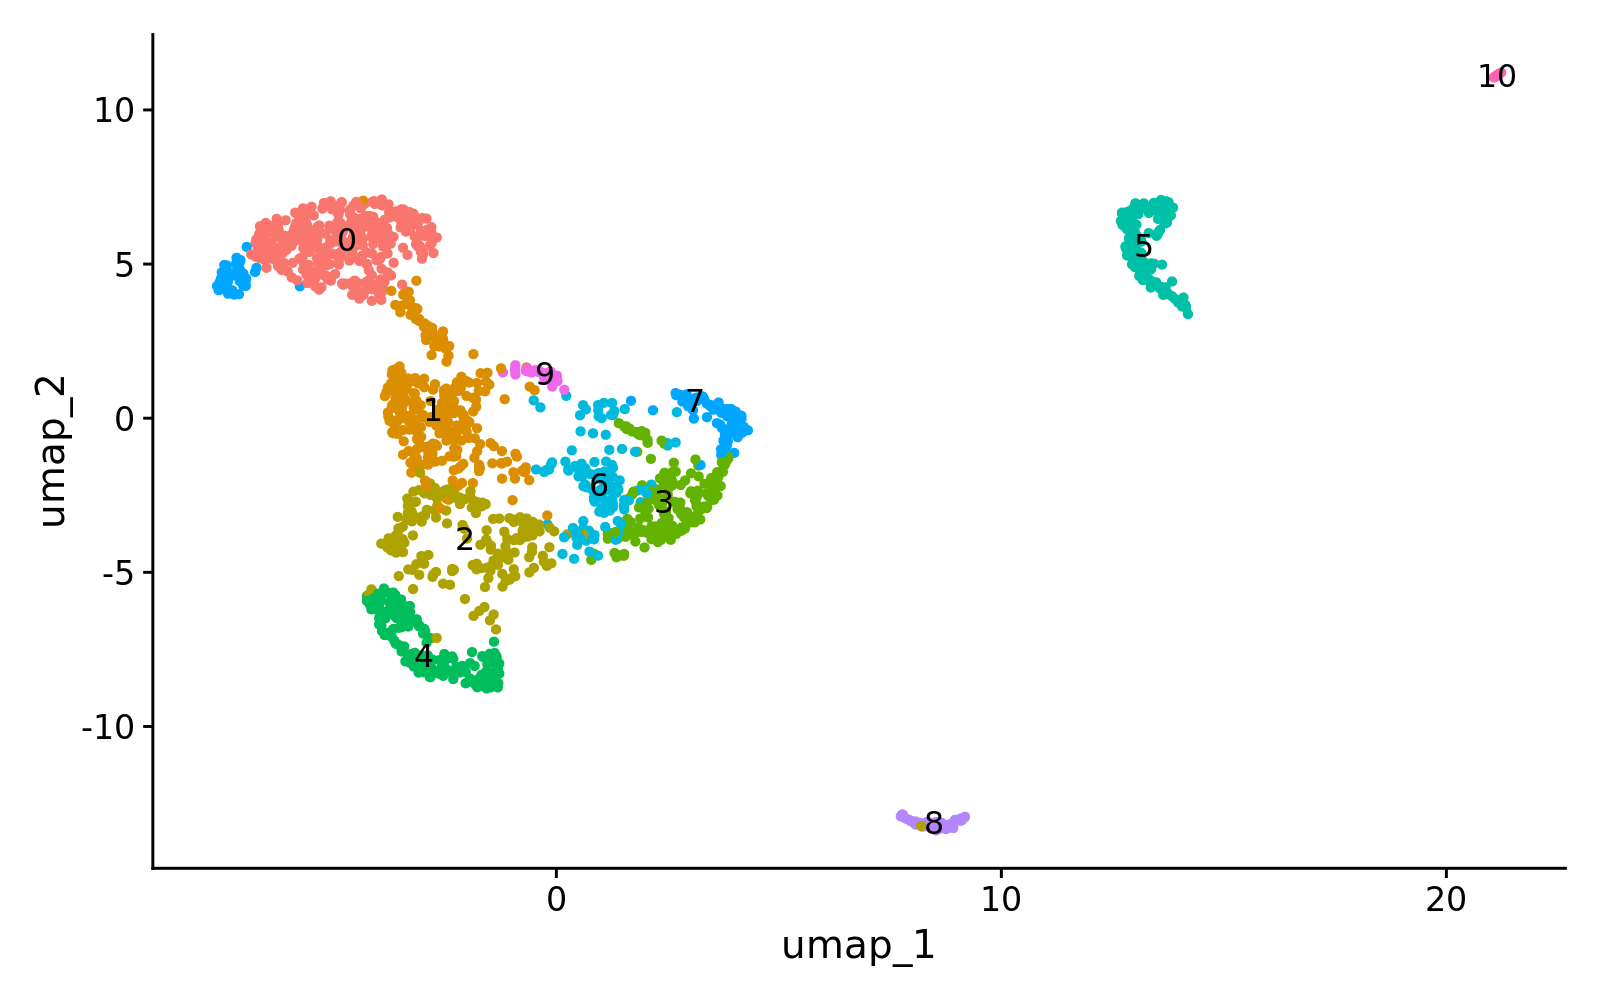

In [51]:
# try a few different UMAP parameters and see how that changes the result!

# here we use a much higher number of neighbors, which will make the UMAP plot more "connected" and less "fragmented"
healthy.pbmc_qc1 <- RunUMAP(healthy.pbmc_qc1, dims = dims_use, n.neighbors = 100, min.dist = 0.3)
DimPlot(healthy.pbmc_qc1, reduction = "umap", label = TRUE) + NoLegend()

20:30:14 UMAP embedding parameters a = 0.115 b = 1.929

20:30:14 Read 1695 rows and found 7 numeric columns

20:30:14 Using Annoy for neighbor search, n_neighbors = 30

20:30:14 Building Annoy index with metric = cosine, n_trees = 50

0%   10   20   30   40   50   60   70   80   90   100%

[----|----|----|----|----|----|----|----|----|----|

*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
*
|

20:30:15 Writing NN index file to temp file /tmp/Rtmpr4N6Hz/filea1f6f429d08

20:30:15 Searching Annoy index using 1 thread, search_k = 3000

20:30:15 Annoy recall = 100%

20:30:16 Commencing smooth kNN distance calibration using 1 thread
 with target n_neighbors = 30

20:30:17 Initializing from normalized Laplacian + noise (using RSpectra)

20:30:17 Commencing optimization for 500 epochs, with 62402 positive edges

20:30:17 Using rng type: pcg

20:30:20 Optimization finished



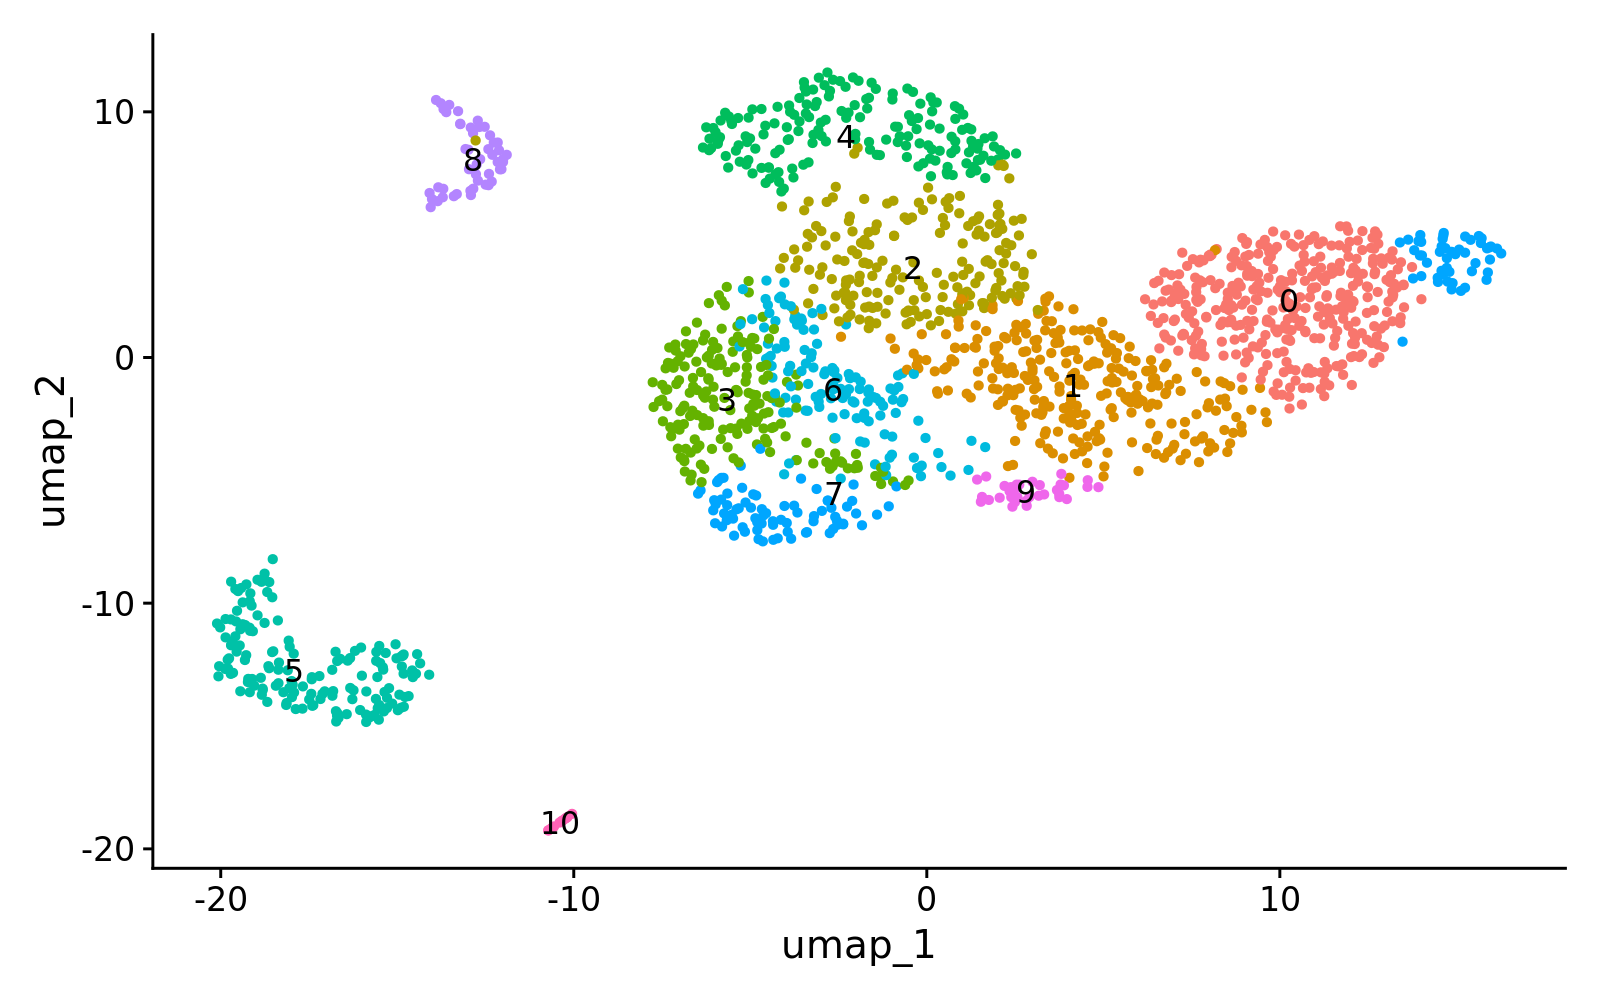

In [52]:
# try a few different UMAP parameters and see how that changes the result!

# here we use a much higher min.dist, which will make the UMAP plot more "spread out" and less "clustered"
healthy.pbmc_qc1 <- RunUMAP(healthy.pbmc_qc1, dims = dims_use, n.neighbors = 30, min.dist = 1)
DimPlot(healthy.pbmc_qc1, reduction = "umap", label = TRUE) + NoLegend()

# Find Marker Genes

Marker genes are defined as those that define each individual cluster. These could be genes that are more highly expressed in one cluster compared to all other clusters, or could be bidirectional (e.g., either higher or lower than in any other cluster). Below, we use the option `only.pos = TRUE`, which indicates the only more highly expressed option.

Note that this analysis can take a few minutes to run, which is why the results are typically saved (in this case in `all_markers.csv` file) for downstream use.

In [46]:
markers <- FindAllMarkers(healthy.pbmc_qc1,
  only.pos = TRUE,
  min.pct = 0.25,
  logfc.threshold = 0.25)

write.csv(markers, "all_markers.csv", row.names = FALSE)

Calculating cluster 0

For a (much!) faster implementation of the Wilcoxon Rank Sum Test,
(default method for FindMarkers) please install the presto package
--------------------------------------------
install.packages('devtools')
devtools::install_github('immunogenomics/presto')
--------------------------------------------
After installation of presto, Seurat will automatically use the more 
efficient implementation (no further action necessary).
This message will be shown once per session

Calculating cluster 1

Calculating cluster 2

Calculating cluster 3

Calculating cluster 4

Calculating cluster 5

Calculating cluster 6

Calculating cluster 7

Calculating cluster 8

Calculating cluster 9

Calculating cluster 10

Calculating cluster 11



In [54]:
head(markers)

,p_val,avg_log2FC,pct.1,pct.2,p_val_adj,cluster,gene
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
RPS3A,2.196755e-121,1.281719,1,0.930,8.480791e-117,0,RPS3A
RPS13,2.824736e-121,1.418554,1,0.843,1.090518e-116,0,RPS13
RPL30,2.218341e-112,1.225329,1,0.901,8.564128e-108,0,RPL30
RPL11,1.288500e-107,1.153830,1,0.905,4.974384e-103,0,RPL11
RPL32,3.348545e-106,1.097886,1,0.918,1.292739e-101,0,RPL32
RPS12,7.532193e-106,1.331454,1,0.863,2.907879e-101,0,RPS12


In [61]:
# what are the top marker genes for each cluster? Do they make sense based on what you know about PBMC biology?

top_markers <- do.call(
    rbind,
    lapply(split(markers, markers$cluster), function(df) {
        df <- df[order(-df$avg_log2FC), ]
        head(df, 10)
    })
)
row.names(top_markers) <- NULL

for (cl in unique(top_markers$cluster)) {
    cat(paste0("Cluster ", cl, " top markers:\n"))
    print(top_markers[top_markers$cluster == cl, c("gene", "avg_log2FC", "p_val_adj")])
    cat("\n")
}
# top_markers

Cluster 0 top markers:
        gene avg_log2FC    p_val_adj
1  CHRM3-AS2   2.735947 1.298562e-53
2       BEX5   2.025201 2.633274e-22
3        MAL   2.013948 9.710094e-52
4     GIMAP1   1.999783 4.264982e-35
5   LEF1-AS1   1.898206 2.245431e-25
6       LDHB   1.799508 2.219144e-84
7      EPHB6   1.766758 6.775526e-19
8  LINC01550   1.733325 1.209956e-24
9       BEX2   1.706008 3.276457e-36
10      NET1   1.674007 1.328779e-23

Cluster 1 top markers:
        gene avg_log2FC    p_val_adj
11    MFHAS1   3.514839 9.360962e-76
12    FHIP1A   2.704937 1.219443e-14
13    ADAM19   2.699979 2.245465e-51
14 LINC02649   2.658952 1.027883e-49
15  ZDHHC11B   2.609183 2.153661e-31
16    ZNF704   2.586162 3.921590e-20
17     GDPD5   2.555916 1.707397e-34
18    MCF2L2   2.483667 2.155784e-25
19     KIF5C   2.462419 2.795789e-39
20     SNED1   2.433567 5.111967e-53

Cluster 2 top markers:
      gene avg_log2FC    p_val_adj
21    CCR4   2.210114 1.741125e-32
22   ANXA1   1.763027 4.398695e-44
23   ISG15

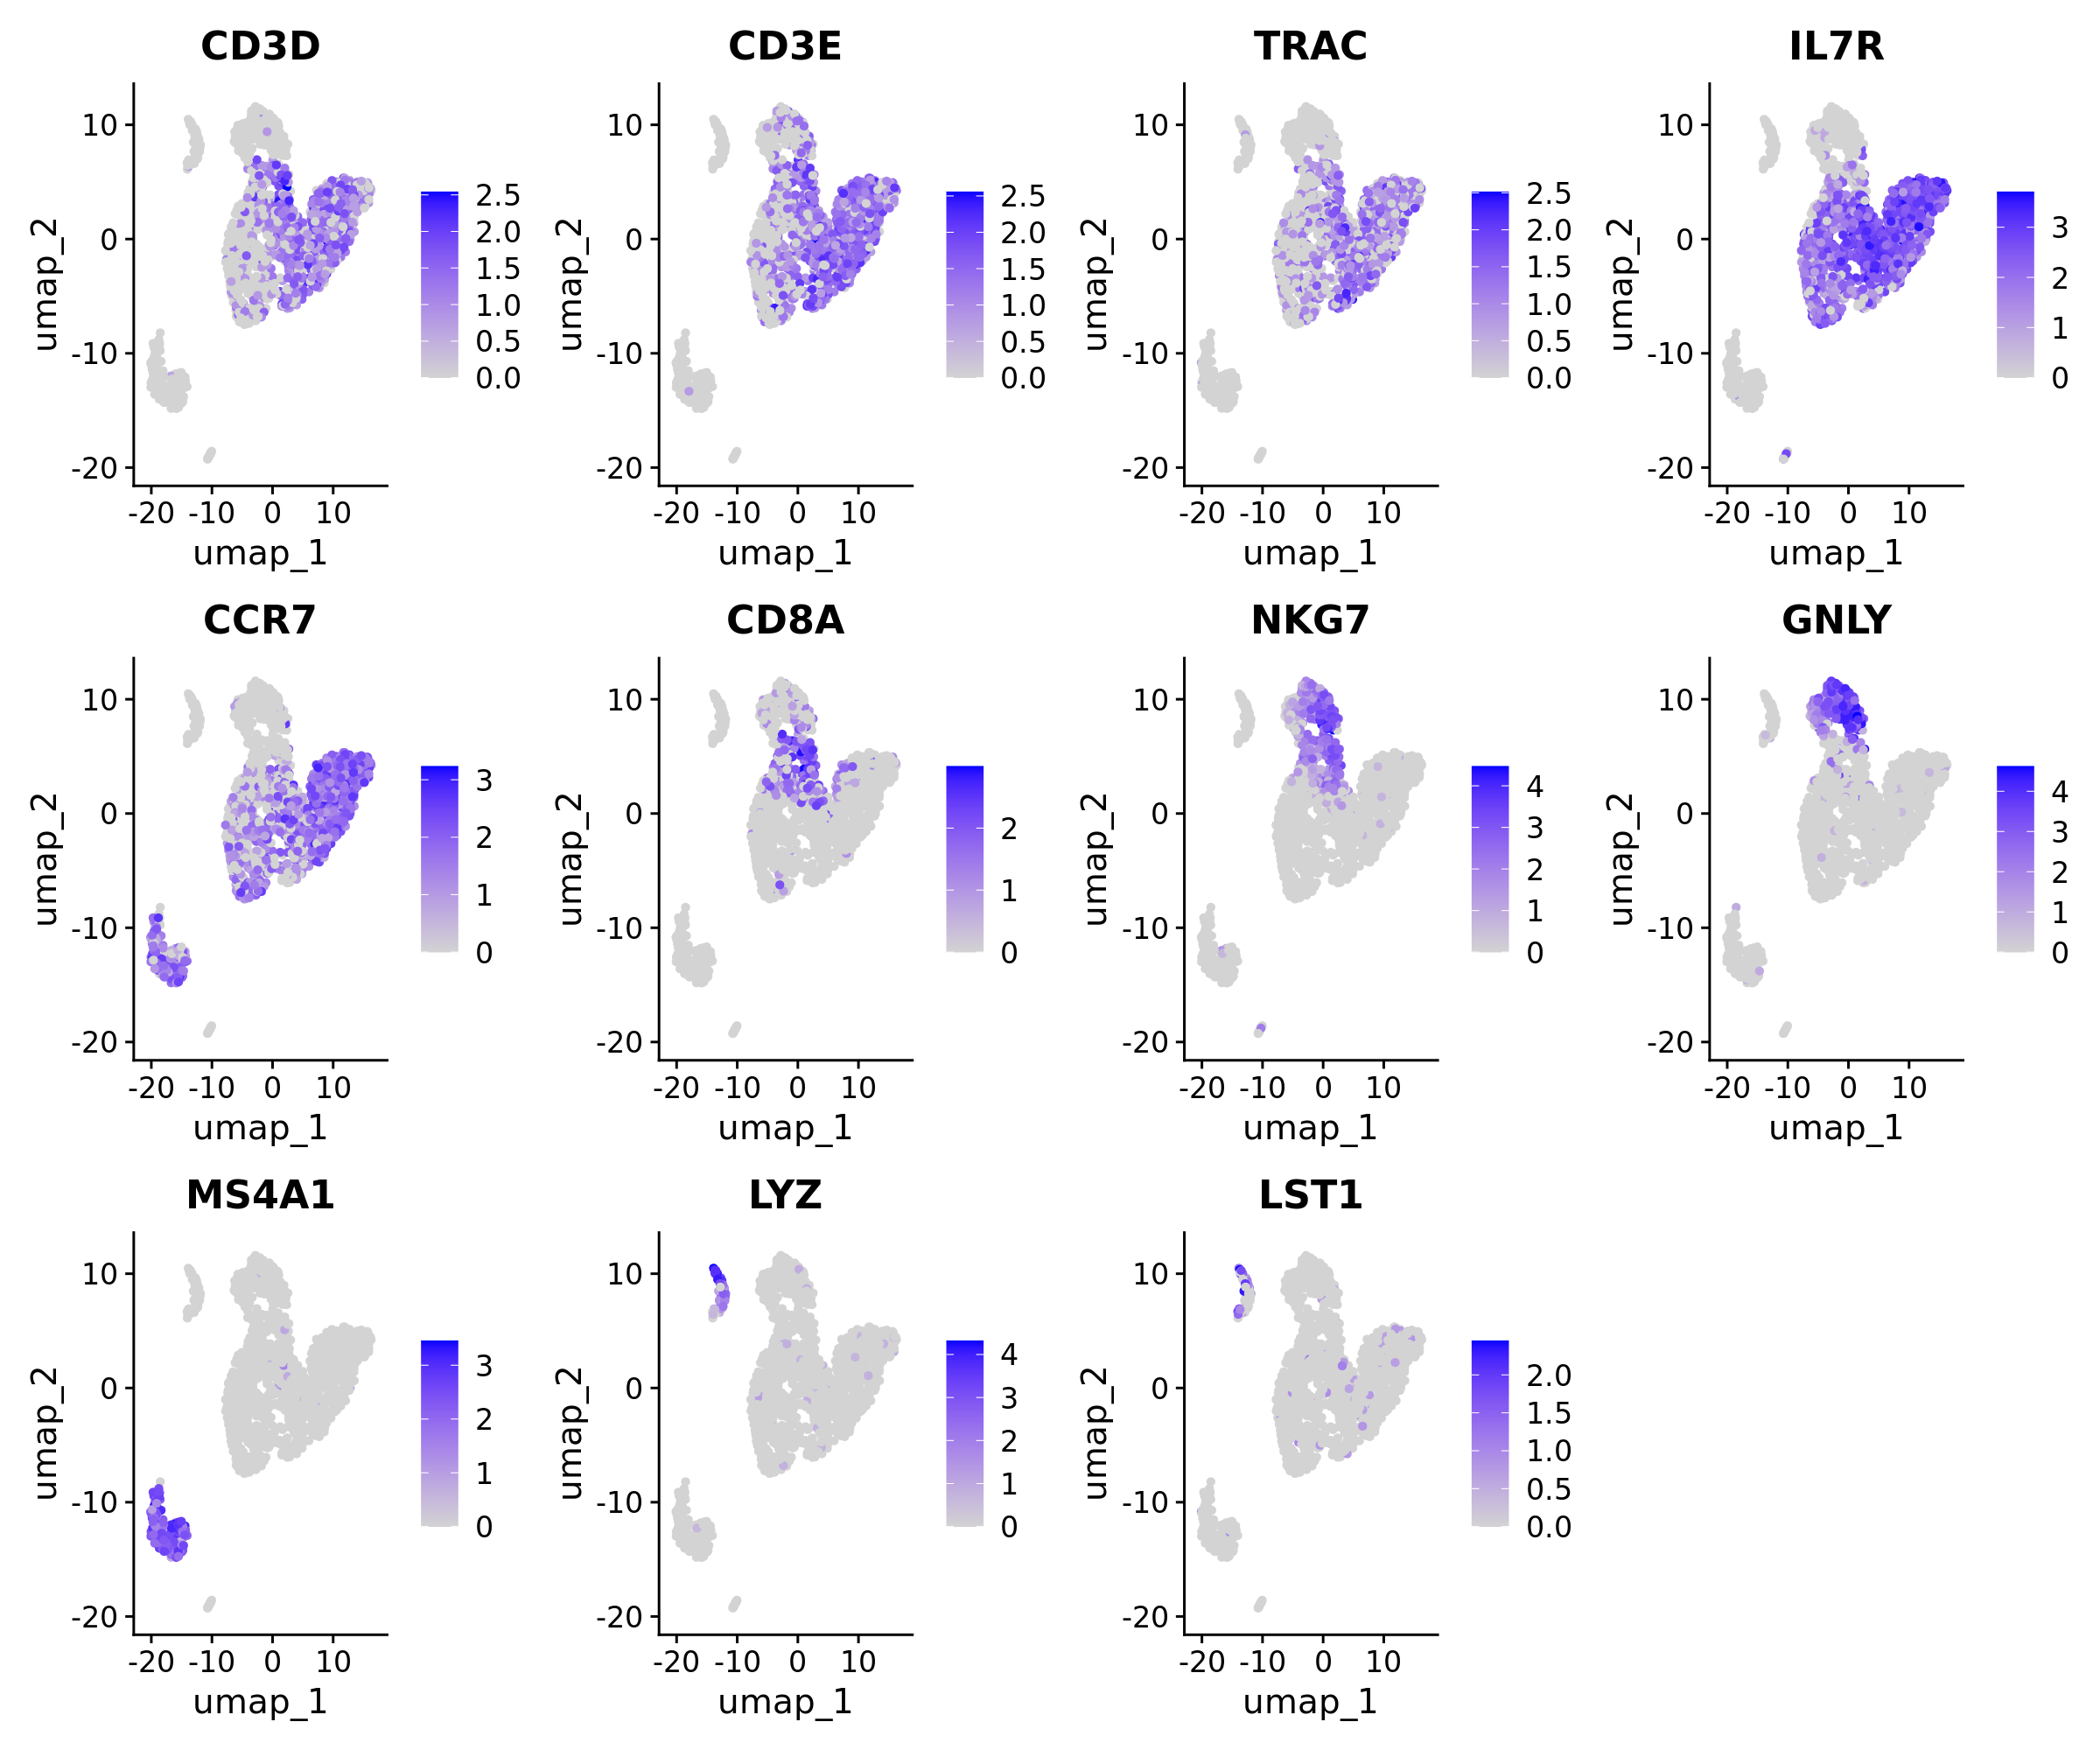

In [59]:
options(repr.plot.width = 12, repr.plot.height = 10, repr.plot.res = 200)

canonical <- c("CD3D","CD3E","TRAC","IL7R","CCR7",
               "CD8A","NKG7","GNLY","MS4A1","LYZ","LST1")

FeaturePlot(healthy.pbmc_qc1, features = canonical, ncol = 4)